In [96]:
from scipy.ndimage import map_coordinates as mp
from scipy.interpolate import interp1d
import numpy as np
import cdflib

fname = r'/home/sroy/Documents/IWF_research/MMS_data/mms1_fpi_brst_l2_dis-dist_20160111005704_v3.3.0.cdf'

cdf = cdflib.CDF(fname)


In [73]:
cdf.cdf_info()

CDFInfo(CDF=PosixPath('/home/sroy/Documents/IWF_research/MMS_data/mms1_fpi_brst_l2_dis-dist_20160111005704_v3.3.0.cdf'), Version='3.6.3', Encoding=6, Majority='Column_major', rVariables=[], zVariables=['Epoch', 'Epoch_plus_var', 'Epoch_minus_var', 'mms1_dis_errorflags_brst', 'mms1_dis_compressionloss_brst', 'mms1_dis_steptable_parity_brst', 'mms1_dis_startdelphi_count_brst', 'mms1_dis_startdelphi_angle_brst', 'mms1_dis_phi_brst', 'mms1_dis_phi_delta_brst', 'mms1_dis_dist_brst', 'mms1_dis_disterr_brst', 'mms1_dis_sector_despinp_brst', 'mms1_dis_sector_label_brst', 'mms1_dis_pixel_label_brst', 'mms1_dis_energy_label_brst', 'mms1_dis_theta_brst', 'mms1_dis_theta_delta_brst', 'mms1_dis_energy_brst', 'mms1_dis_energy_delta_brst'], Attributes=[{'Project': 'Global'}, {'Source_name': 'Global'}, {'Discipline': 'Global'}, {'Data_type': 'Global'}, {'Descriptor': 'Global'}, {'File_naming_convention': 'Global'}, {'Data_version': 'Global'}, {'PI_name': 'Global'}, {'PI_affiliation': 'Global'}, {'TEXT

In [113]:
E_bins = cdf.varget('mms1_dis_energy_brst')
theta_bins = cdf.varget('mms1_dis_theta_brst')
phi_bins = cdf.varget('mms1_dis_phi_brst')[0]

In [115]:
# Convert theta and phi to radians
theta_bins = np.deg2rad(theta_bins)
phi_bins = np.deg2rad(phi_bins)

In [79]:
dist = cdf.varget('mms1_dis_dist_brst')

In [82]:
q = 1.6e-19
m = 1.7e-27

In [83]:
E_bins[0]

v_bins = np.sqrt(2*q*E_bins[0]/m)

In [84]:
v_bins

array([4.7645750e+04, 5.3997816e+04, 6.1188230e+04, 6.9349922e+04,
       7.8599508e+04, 8.9084227e+04, 1.0096009e+05, 1.1442747e+05,
       1.2968014e+05, 1.4697578e+05, 1.6657659e+05, 1.8878683e+05,
       2.1396427e+05, 2.4249680e+05, 2.7483300e+05, 3.1148069e+05,
       3.5301725e+05, 4.0009175e+05, 4.5344381e+05, 5.1391184e+05,
       5.8244106e+05, 6.6011050e+05, 7.4813650e+05, 8.4790012e+05,
       9.6096812e+05, 1.0891136e+06, 1.2343469e+06, 1.3989474e+06,
       1.5854978e+06, 1.7969244e+06, 2.0365450e+06, 2.3081192e+06],
      dtype=float32)

In [87]:
vx = vy = vz = np.linspace(-2e6, 2e6, 100)

In [138]:
VX, VY, VZ = np.meshgrid(vx, vy, vz, indexing='ij')

In [139]:
V = np.sqrt(VX**2 + VY**2 + VZ**2)

THETA = np.arccos(np.clip(VZ / (V + 1e-12), -1, 1))
PHI = np.arctan2(VY, VX)
PHI[PHI < 0] += 2*np.pi

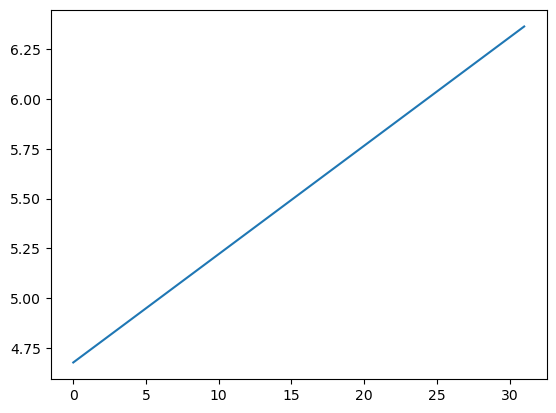

In [95]:
plt.plot(np.log10(v_bins))

In [145]:
theta_index = theta_bins/(theta_bins[1] - theta_bins[0])

In [146]:
theta_index

array([ 0.49999997,  1.4999999 ,  2.4999998 ,  3.4999998 ,  4.4999995 ,
        5.499999  ,  6.5       ,  7.4999995 ,  8.499999  ,  9.499999  ,
       10.499998  , 11.499999  , 12.5       , 13.499999  , 14.499999  ,
       15.499999  ], dtype=float32)

In [150]:
np.sort(THETA.ravel())

array([0.01428401, 0.01428401, 0.01428401, ..., 3.12730864, 3.12730864,
       3.12730864], shape=(1000000,))

In [127]:
iv = interp1d(np.log10(v_bins), np.arange(len(v_bins)))
itheta = interp1d(theta_bins, np.arange(len(theta_bins)), bounds_error=False, fill_value=np.nan)
iphi = interp1d(phi_bins, np.arange(len(phi_bins)), bounds_error=False, fill_value=np.nan)

In [128]:
new_theta = itheta(THETA.ravel())
new_phi = iphi(PHI.ravel())

In [129]:
new_theta

array([nan, nan, nan, ..., nan, nan, nan], shape=(1000000,))

In [130]:
phi_bins

array([0.06872234, 0.26507187, 0.46142143, 0.65777093, 0.8541205 ,
       1.05047   , 1.2468196 , 1.4431691 , 1.6395186 , 1.8358682 ,
       2.0322177 , 2.2285674 , 2.4249167 , 2.6212664 , 2.817616  ,
       3.0139654 , 3.210315  , 3.4066646 , 3.603014  , 3.7993636 ,
       3.9957132 , 4.192063  , 4.388412  , 4.5847616 , 4.7811112 ,
       4.977461  , 5.1738105 , 5.37016   , 5.5665092 , 5.762859  ,
       5.9592085 , 6.155558  ], dtype=float32)

In [131]:
new_phi

array([19.64999975, 19.64999975, 19.64999975, ...,  3.65000009,
        3.65000009,  3.65000009], shape=(1000000,))

In [132]:
PHI.ravel()

array([3.92699082, 3.92699082, 3.92699082, ..., 0.78539816, 0.78539816,
       0.78539816], shape=(1000000,))

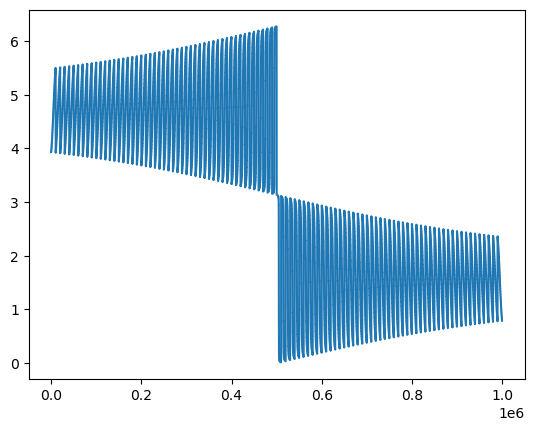

In [137]:
plt.plot(PHI.ravel())